In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

import duckdb
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, recall_score, precision_score, roc_curve, confusion_matrix, auc, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [2]:
conn = duckdb.connect(r'C:\Users\Pichau\OneDrive\Documentos\Estudos Dudu\7. atraso-voos\data\features.duckdb')

In [3]:
df = pd.read_sql_query("SELECT * FROM fs_general_abt", conn)

C:\Users\Pichau\AppData\Local\Temp\ipykernel_12220\1169696912.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT * FROM fs_general_abt", conn)


In [4]:
df.head()

,idVoo,flagAtraso,avgPrecipitacaoTotal24h,avgPressaoAtmosferica24h,avgPressaoAtmosfericaMaxUltimaHora24h,avgPressaoAtmosfericaMinUltimaHora24h,avgTemperaturaBulboSeco24h,avgTemperaturaPontoOrvalho24h,avgTemperaturaMaxUltimaHora24h,avgTemperaturaMinUltimaHora24h,...,partidaMes,partidaDiaSemana,partidaFinalDeSemana,partidaDiaAno,partidaSemanaAno,partidaHora,partidaPeriodoDia,partidaHoraMinutoDecimal,partidaAltaTemporada,partidaDiaQuinzena
0,AZU-4082-SBCF-SBKP-202404111950-202404112105,0,0.0,917.504171,917.758334,917.279165,25.125000,17.225000,25.862500,24.529167,...,4,4,0,102,15,19,Noite,19.833333,0,11
1,TAM-3557-SBCF-SBGR-202404111955-202404112115,0,0.0,917.504171,917.758334,917.279165,25.125000,17.225000,25.862500,24.529167,...,4,4,0,102,15,19,Noite,19.916667,0,11
2,GLO-1705-SBCF-SBBR-202404111815-202404111935,0,0.0,917.454173,917.708336,917.224998,25.041667,17.058333,25.845833,24.445833,...,4,4,0,102,15,18,Noite,18.250000,0,11
3,TAM-3555-SBCF-SBGR-202404111455-202404111610,0,0.0,917.291674,917.541669,917.054169,25.020833,16.733333,25.825000,24.441667,...,4,4,0,102,15,14,Tarde,14.916667,0,11
4,AZU-4729-SBCF-SBBE-202404080835-202404081135,1,0.0,920.133334,920.350004,919.929169,22.891667,15.629167,23.679167,21.970833,...,4,1,0,99,15,8,Manha,8.583333,0,8


# CORRELAÇÃO DE VARIAVEIS

In [5]:
df_target_corr = df.select_dtypes(include='number').corr()['flagAtraso']

In [6]:
df.columns

Index(['idVoo', 'flagAtraso', 'avgPrecipitacaoTotal24h',
       'avgPressaoAtmosferica24h', 'avgPressaoAtmosfericaMaxUltimaHora24h',
       'avgPressaoAtmosfericaMinUltimaHora24h', 'avgTemperaturaBulboSeco24h',
       'avgTemperaturaPontoOrvalho24h', 'avgTemperaturaMaxUltimaHora24h',
       'avgTemperaturaMinUltimaHora24h',
       ...
       'partidaMes', 'partidaDiaSemana', 'partidaFinalDeSemana',
       'partidaDiaAno', 'partidaSemanaAno', 'partidaHora', 'partidaPeriodoDia',
       'partidaHoraMinutoDecimal', 'partidaAltaTemporada',
       'partidaDiaQuinzena'],
      dtype='str', length=194)

In [7]:
corr_features = df_target_corr.to_frame().sort_values(by='flagAtraso', ascending=False).reset_index()

In [8]:
corr_features[corr_features['index'].str.contains('Intervalo')]


,index,flagAtraso
119,voosConfinsIntervalo2h,0.018687
138,voosConfinsIntervalo1h,-0.003157
148,voosMesmaEmpresaIntervalo2h,-0.012497
151,voosConfinsIntervalo30min,-0.017705
155,voosConfinsIntervalo15min,-0.022034
157,voosMesmaEmpresaIntervalo1h,-0.023691
162,voosMesmaEmpresaIntervalo30min,-0.030581
163,voosMesmaEmpresaIntervalo15min,-0.032141


# DESBALANCEAMENTO DE CLASSES

In [9]:
df['flagAtraso'].value_counts()[1]/len(df) * 100

np.float64(7.858057598951664)

# ANALISE DE VARIAVEIS CONSTANTES

In [10]:
from sklearn.feature_selection import VarianceThreshold

var_thres = VarianceThreshold(threshold=10)
var_thres.fit(df.drop(columns=['idVoo','flagAtraso','']))

var_thres

KeyError: "[''] not found in axis"

In [ ]:
var_thres.get_support()

array([False, False, False, False, False,  True, False, False,  True,
        True,  True,  True,  True,  True, False, False, False, False,
       False, False, False,  True,  True, False,  True,  True,  True,
        True,  True,  True, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False, False,  True, False, False, False, False,  True,
       False, False,  True,  True,  True,  True,  True,  True, False,
       False,  True, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True, False, False,  True, False, False,  True, False,
        True, False, False,  True, False, False, False, False, False,
       False,  True,

In [ ]:
for idx, i in enumerate(var_thres.get_support()):
    if i == False:
        print(df.columns[idx])

idVoo
flagAtraso
avgPrecipitacaoTotal24h
avgPressaoAtmosferica24h
avgPressaoAtmosfericaMaxUltimaHora24h
avgTemperaturaBulboSeco24h
avgTemperaturaPontoOrvalho24h
avgUmidadeRelativa24h
avgVentoDirecaoGraus24h
avgVentoRajadaMax24h
avgVentoVelocidade24h
avgPrecipitacaoTotal12h
avgPressaoAtmosferica12h
avgPressaoAtmosfericaMaxUltimaHora12h
avgTemperaturaPontoOrvalho12h
avgUmidadeRelativa12h
avgVentoDirecaoGraus12h
avgVentoRajadaMax12h
avgUmidadeRelativa3h
avgVentoDirecaoGraus3h
avgVentoVelocidade3h
maxPrecipitacaoTotal24h
maxPressaoAtmosferica24h
maxPressaoAtmosfericaMaxUltimaHora24h
maxTemperaturaBulboSeco24h
maxTemperaturaPontoOrvalho24h
maxUmidadeRelativa24h
maxVentoDirecaoGraus24h
maxVentoVelocidade24h
maxPrecipitacaoTotal12h
maxPressaoAtmosferica12h
maxUmidadeRelativa12h
maxVentoDirecaoGraus12h
maxVentoRajadaMax12h
maxUmidadeRelativa3h
maxVentoDirecaoGraus3h
maxVentoRajadaMax3h
maxVentoVelocidade3h
stddevPrecipitacaoTotal24h
stddevPressaoAtmosferica24h
stddevPressaoAtmosfericaMaxUltima

# MODELING 1

In [11]:
X = df.drop(columns=['idVoo','flagAtraso'])
#X = X.drop(columns=['partidaPeriodoDia','aerodromoDestino', 'empresaAerea', 'numeroVoo'])
y = df['flagAtraso']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

In [12]:
len(X_train)

141023

In [13]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    eval_metric='Recall',
    early_stopping_rounds=50,
    verbose=100,
    scale_pos_weight= 8,
    cat_features=['partidaPeriodoDia','aerodromoDestino', 'empresaAerea', 'numeroVoo']
)


model.fit(
    X_train, y_train,               
    eval_set=[(X_val, y_val)],  
    use_best_model=True
)

0:	learn: 0.3014799	test: 0.2792755	best: 0.2792755 (0)	total: 263ms	remaining: 4m 22s
100:	learn: 0.4143656	test: 0.3820556	best: 0.3820556 (99)	total: 11s	remaining: 1m 38s
200:	learn: 0.4398123	test: 0.3967987	best: 0.3984836 (197)	total: 21.1s	remaining: 1m 23s
300:	learn: 0.4627324	test: 0.3980623	best: 0.3997473 (280)	total: 31.3s	remaining: 1m 12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.399747262
bestIteration = 280

Shrink model to first 281 iterations.


CatBoostClassifier(cat_features=['partidaPeriodoDia', 'aerodromoDestino', 'empresaAerea', 'numeroVoo'], depth=6, early_stopping_rounds=50, eval_metric='Recall', iterations=1000, l2_leaf_reg=5, learning_rate=0.05, scale_pos_weight=8, verbose=100)

In [14]:
# Predições
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

y_pred_adj = (y_proba >= 0.51).astype(int)  # Ajuste do limiar para 0.3

In [15]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_proba)
recall = recall_score(y_test, y_pred_adj)
acc = accuracy_score(y_test, y_pred_adj)
precision = precision_score(y_test, y_pred_adj)
print(f"Novo ROC AUC: {auc}")
print(f"Novo Recall: {recall}")
print(f"Nova Accuracy: {acc}")
print(f"Nova Precision: {precision}")

Novo ROC AUC: 0.7116157374942114
Novo Recall: 0.4113684210526316
Nova Accuracy: 0.8256121773659828
Nova Precision: 0.20148484223551247


In [16]:
importances = pd.Series(model.feature_importances_, index=X.columns)
for k,v in importances.sort_values(ascending=False).items():
    print(f"{k}: {v:.4f}")

pct_atrasosCia24h: 6.7353
numeroVoo: 4.7665
partidaHoraMinutoDecimal: 4.7532
partidaHora: 3.3263
empresaAerea: 2.6015
voosConfinsIntervalo2h: 2.4632
partidaPeriodoDia: 2.3614
atrasos12h: 2.3281
aerodromoDestino: 1.4920
atrasos24h: 1.4588
ratio_atrasosCia12h_24h: 1.3109
voosMesmaEmpresaIntervalo1h: 1.1475
voosMesmaEmpresaIntervalo2h: 1.1301
ratio_atrasosCia3h_24h: 1.1116
voos24h: 1.1019
maxVentoVelocidade12h: 1.0836
cancelamentos24h: 1.0795
atrasos3h: 1.0575
ratio_atrasos3h_24h: 1.0556
partidaDiaSemana: 1.0516
pct_atrasos24h: 1.0131
partidaDiaAno: 0.9676
avgTemperaturaPontoOrvalhoMaxUltimaHora3h: 0.9532
voosCia24h: 0.9400
maxVentoRajadaMax24h: 0.9227
atrasosCia24h: 0.9196
pct_atrasosCiaRota24h: 0.8832
maxVentoRajadaMax12h: 0.8271
partidaSemanaAno: 0.8224
cancelamentosCia12h: 0.7966
deltaPartida_minutos: 0.7960
stddevVentoVelocidade24h: 0.7159
maxVentoDirecaoGraus3h: 0.7107
avgVentoVelocidade24h: 0.7104
stddevPressaoAtmosfericaMaxUltimaHora24h: 0.6704
avgVentoVelocidade3h: 0.6677
ratio_a

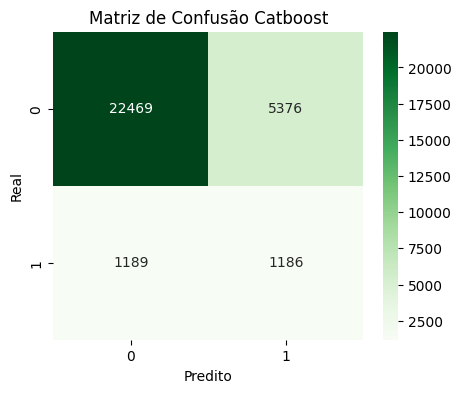

In [ ]:
cm = confusion_matrix(y_test, y_pred_adj)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f"Matriz de Confusão Catboost")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

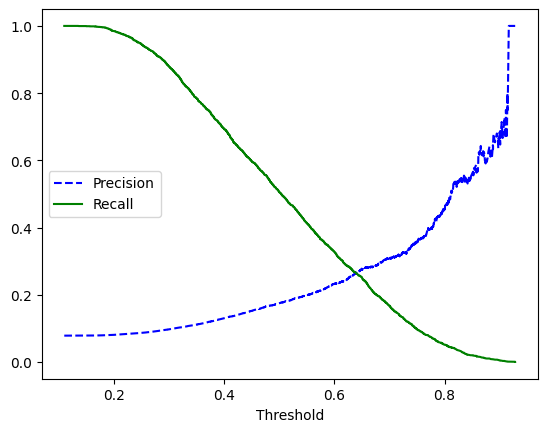

In [61]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()


In [62]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Obter curvas
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# 2. Calcular F1 para cada threshold disponível
# (Adicionamos um pequeno valor para evitar divisão por zero)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# 3. Achar o índice do maior F1
idx_melhor = np.argmax(f1_scores)
best_threshold = thresholds[idx_melhor]

print(f"Melhor Threshold (F1): {best_threshold:.4f}")

Melhor Threshold (F1): 0.5968


In [63]:
beta = 0.5 # Peso 0.5 foca mais em Precision. Beta 2.0 focaria em Recall.
f_beta_scores = (1 + beta**2) * (precisions * recalls) / ((beta**2 * precisions) + recalls + 1e-10)

idx_fbeta = np.argmax(f_beta_scores)
threshold_fbeta = thresholds[idx_fbeta]

print(f"Melhor Threshold (F-0.5): {threshold_fbeta:.4f}")

Melhor Threshold (F-0.5): 0.6495


In [142]:
for k,v in importances.sort_values(ascending=False).items():
    print(f"{k}: {v:.4f}")

voosMesmaEmpresaIntervalo15min: 3.1827
partidaMes: 2.5415
partidaDiaMes: 2.1485
cancelamentosCia24h: 1.8921
stddevVentoVelocidade24h: 1.8009
atrasosCiaRota12h: 1.7847
avgTemperaturaPontoOrvalhoMaxUltimaHora3h: 1.7679
maxTemperaturaMaxUltimaHora24h: 1.7158
maxTemperaturaBulboSeco12h: 1.6676
avgVentoDirecaoGraus3h: 1.6456
avgVentoDirecaoGraus24h: 1.6213
stddevVentoDirecaoGraus24h: 1.6150
maxTemperaturaMaxUltimaHora3h: 1.5545
stddevVentoRajadaMax24h: 1.5343
stddevTemperaturaPontoOrvalhoMaxUltimaHora24h: 1.5135
avgVentoRajadaMax24h: 1.5133
avgVentoVelocidade24h: 1.4810
partidaDiaQuinzena: 1.4783
voosConfinsIntervalo15min: 1.4241
maxVentoDirecaoGraus24h: 1.3835
cancelamentos12h: 1.3601
maxVentoDirecaoGraus12h: 1.3289
avgVentoVelocidade12h: 1.2459
maxVentoVelocidade12h: 1.2386
avgTemperaturaBulboSeco12h: 1.1266
avgVentoRajadaMax12h: 1.1191
stddevTemperaturaPontoOrvalhoMinUltimaHora24h: 1.1017
avgTemperaturaMaxUltimaHora3h: 1.0657
stddevTemperaturaMaxUltimaHora24h: 1.0276
vooDomestico: 0.9595

## MODELING UNDERSAMPLING

In [69]:
from imblearn.under_sampling import RandomUnderSampler

# Se você quer que a classe minoritária seja 25% do total (proporção 1:3)
# sampling_strategy = (positivos) / (negativos desejados) -> 14000 / 42000 = 0.33
rus = RandomUnderSampler(sampling_strategy=0.33, random_state=42)

X_res, y_res = rus.fit_resample(X_train, y_train)

print(f"Novo tamanho do treino: {len(X_res)} linhas")

Novo tamanho do treino: 44663 linhas


In [72]:
# Se você usou o Undersampling para chegar em 1:3 ou 1:2
model_under = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    eval_metric='Recall', # Foca na métrica que você quer melhorar
    early_stopping_rounds=50,
    verbose=100,
    scale_pos_weight=20
)

# Se você NÃO usar undersampling, adicione: auto_class_weights='Balanced'
# Se usar o undersampling, pode deixar sem ou testar um peso leve

model_under.fit(
    X_res, y_res,               # Dados balanceados (treino)
    #eval_set=(X_test, y_test),  # Validação nos dados REAIS (com os 7%)
    use_best_model=True
)

You should provide test set for use best model. use_best_model parameter has been switched to false value.


0:	learn: 1.0000000	total: 19.7ms	remaining: 19.7s
100:	learn: 1.0000000	total: 2.14s	remaining: 19.1s
200:	learn: 1.0000000	total: 4.08s	remaining: 16.2s
300:	learn: 1.0000000	total: 5.89s	remaining: 13.7s
400:	learn: 1.0000000	total: 7.67s	remaining: 11.4s
500:	learn: 1.0000000	total: 9.45s	remaining: 9.41s
600:	learn: 1.0000000	total: 11.2s	remaining: 7.41s
700:	learn: 1.0000000	total: 12.9s	remaining: 5.5s
800:	learn: 1.0000000	total: 14.6s	remaining: 3.63s
900:	learn: 1.0000000	total: 16.3s	remaining: 1.79s
999:	learn: 1.0000000	total: 18s	remaining: 0us


CatBoostClassifier(depth=6, early_stopping_rounds=50, eval_metric='Recall', iterations=1000, l2_leaf_reg=5, learning_rate=0.05, scale_pos_weight=20, verbose=100)

In [73]:
# Predições
y_pred_under = model_under.predict(X_test)
y_proba_under = model_under.predict_proba(X_test)[:, 1]

In [74]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_proba_under)
print(f"Novo ROC AUC: {auc}")

Novo ROC AUC: 0.6977031597431876


In [75]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_under))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.05      0.09     55690
           1       0.08      0.98      0.15      4749

    accuracy                           0.12     60439
   macro avg       0.52      0.51      0.12     60439
weighted avg       0.90      0.12      0.09     60439



In [ ]:
ddd

NameError: name 'ddd' is not defined

In [48]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

# 1. Pegue as probabilidades (em vez das classes 0/1)
y_probs = model_under.predict_proba(X_test)[:, 1]
y_pred = model_under.predict(X_test)

# 2. Teste vários thresholds para encontrar o melhor F1
thresholds = np.linspace(0, 1, 1000)
f1_scores = [recall_score(y_test, y_pred >= t) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Melhor Threshold: {best_threshold:.4f}")

# 3. Gere o relatório com o novo threshold
y_pred_novo = (y_probs >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_novo))


Melhor Threshold: 0.0000
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     55690
           1       0.08      1.00      0.15      4749

    accuracy                           0.08     60439
   macro avg       0.04      0.50      0.07     60439
weighted avg       0.01      0.08      0.01     60439



c:\Users\Pichau\OneDrive\Documentos\Estudos Dudu\7. atraso-voos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Pichau\OneDrive\Documentos\Estudos Dudu\7. atraso-voos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Pichau\OneDrive\Documentos\Estudos Dudu\7. atraso-voos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

In [49]:
best_threshold

np.float64(0.0)

In [ ]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score

# --- 1. CONFIGURAÇÃO E TREINO DO MODELO ---
# Nota: Substitua 'X_train' e 'y_train' pelas suas variáveis reais.
# Se houver colunas categóricas (ex: texto), adicione o parâmetro cat_features=[lista_de_indices]

model_balanced = CatBoostClassifier(
    iterations=1500,  # Aumentado para dar margem ao Early Stopping com 170 colunas
    learning_rate=0.04,  # Taxa ideal para o volume de dados e iterações
    depth=8,  # Árvores mais profundas para capturar interações entre as 170 colunas
    l2_leaf_reg=3,  # Regularização leve para evitar overfitting
    eval_metric="AUC",  # Foco na otimização da separação das classes
    auto_class_weights="Balanced",  # <--- Trata os 7% de forma nativa sem deletar dados
    early_stopping_rounds=100,  # Interrompe o treino se o AUC de teste parar de subir
    random_seed=42,
    verbose=100,  # Exibe o progresso a cada 100 árvores
)

print("Iniciando o treinamento do CatBoost...")
model_balanced.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),  # <--- Validação correta na proporção real
    use_best_model=True,
)

# --- 2. AVALIAÇÃO DA MÉTRICA ROC AUC ---
# Extração das probabilidades da classe 1 (positiva)
y_probs = model_balanced.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_probs)
print(f"\n==========================================")
print(f"Novo ROC AUC no conjunto de teste: {auc:.4f}")
print(f"==========================================\n")

# --- 3. OTIMIZAÇÃO DO THRESHOLD (CORTE DE DECISÃO) ---
print("Otimizando o threshold para maximizar o F1-Score da classe 1...")
thresholds = np.linspace(0.01, 0.99, 200)
f1_scores = []

# Loop para testar qual ponto de corte entrega o melhor resultado prático
for t in thresholds:
    y_pred_temp = (y_probs >= t).astype(int)
    # Calculamos o F1 olhando especificamente para a classe 1 (pos_label=1)
    f1_scores.append(f1_score(y_test, y_pred_temp, pos_label=1))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Melhor Threshold Encontrado: {best_threshold:.4f}")
print(f"Melhor F1-Score da Classe 1: {best_f1:.4f}\n")

# --- 4. RELATÓRIO FINAL DE CLASSIFICAÇÃO ---
y_pred_final = (y_probs >= best_threshold).astype(int)

print("Relatório de Classificação Final (Com Threshold Otimizado):")
print(classification_report(y_test, y_pred_final, digits=4))


Iniciando o treinamento do CatBoost...
0:	test: 0.6532462	best: 0.6532462 (0)	total: 99.7ms	remaining: 2m 29s
100:	test: 0.6946305	best: 0.6946305 (100)	total: 7.36s	remaining: 1m 41s
200:	test: 0.7017165	best: 0.7017165 (200)	total: 14.1s	remaining: 1m 31s
300:	test: 0.7047350	best: 0.7047751 (295)	total: 20.9s	remaining: 1m 23s
400:	test: 0.7076476	best: 0.7076599 (398)	total: 27.6s	remaining: 1m 15s
500:	test: 0.7079762	best: 0.7083986 (463)	total: 34.4s	remaining: 1m 8s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7083986267
bestIteration = 463

Shrink model to first 464 iterations.

Novo ROC AUC no conjunto de teste: 0.7084

Otimizando o threshold para maximizar o F1-Score da classe 1...
Melhor Threshold Encontrado: 0.6059
Melhor F1-Score da Classe 1: 0.2718

Relatório de Classificação Final (Com Threshold Otimizado):
              precision    recall  f1-score   support

           0     0.9423    0.8890    0.9149     55690
           1     0.2176    0.362

# MDELING PADRAO

In [ ]:
modelos = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight='balanced_subsample'
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "CatBoost": CatBoostClassifier(
        verbose=0,
        auto_class_weights='Balanced',
        random_state=42
    ),

    "XGBoost": XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    random_state=42
    ),
}

In [ ]:
def avaliar_modelo(modelo, X_train, X_test, y_train, y_test, nome_modelo="Modelo"):
    
    # Treinamento
    modelo.fit(X_train, y_train)
    
    # Predições
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*60}")
    print(f"AVALIAÇÃO - {nome_modelo}")
    print(f"{'='*60}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # ROC AUC
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC AUC: {auc:.4f}")
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f"Matriz de Confusão [{nome_modelo}]")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure(figsize=(8,6))

    plt.plot(

        fpr,
        tpr,
        label=f"ROC Curve (AUC = {auc:.3f})"

    )

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(f"Curva ROC [{nome_modelo}]")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

    try:
        importances = pd.Series(modelo.feature_importances_, index=X.columns)
        importances.nlargest(10).plot(kind='barh', title='Top 10 Feature Importance')
        plt.show()
    except:
        print("Modelo não possui feature_importances_")

In [ ]:
resultados = []

for nome, modelo in modelos.items():
    resultado = avaliar_modelo(
        modelo,
        X_train,
        X_test,
        y_train,
        y_test,
        nome
    )
    
    resultados.append(resultado)

KeyboardInterrupt: 